# Implementacion

Fuente de los datos: https://www.datos.gov.co/Minas-y-Energ-a/Consulta-Precios-Promedio-de-Gas-Natural-Comprimid/he3q-86dn/about_data

## Importacion de librerias

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

## funciones usadas

In [28]:
def Summary(data, sheet):
    print(f"Hoja: {sheet}")

    # Crear la tabla de resumen
    resumen = {
        "Cantidad de filas": data.shape[0],
        "Cantidad de columnas": data.shape[1],
        "Datos faltantes": data.isnull().sum().sum(),
        "Filas duplicadas": data.duplicated().sum()
    }

    # Convertir el resumen en un DataFrame
    ResumenHoja = pd.DataFrame(resumen, index=["Resumen"])
    print("\nResumen:")
    display(ResumenHoja)

    print("\nEncabezado:")
    display(data.head())

## Cargado inicial de los datos

In [29]:
df = pd.read_csv("precios.csv")

In [30]:
Summary(df, "Datos")

Hoja: Datos

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,10870,12,0,0



Encabezado:


,FECHA_PRECIO,ANIO_PRECIO,MES_PRECIO,DIA_PRECIO,DEPARTAMENTO_EDS,MUNICIPIO_EDS,NOMBRE_COMERCIAL_EDS,PRECIO_PROMEDIO_PUBLICADO,TIPO_COMBUSTIBLE,CODIGO_MUNICIPIO_DANE,LATITUD_MUNICIPIO,LONGITUD_MUNICIPIO
0,2024-2-01,2024,2,1,VALLE DEL CAUCA,CALI,ESTACION DE SERVICIO AVENIDA SUR GAS VEHICULAR,"2,817",GNCV,76001,3.41369,-76.521
1,2025-5-01,2025,5,1,ANTIOQUIA,MEDELLIN,EDS ESSO CASTILLA,"3,490",GNCV,5001,6.24663,-75.581
2,2022-11-01,2022,11,1,VALLE DEL CAUCA,CALI,ESTACION DE SERVICIO EL CAMBIO S.A.S,"2,287",GNCV,76001,3.41369,-76.521
3,2021-1-01,2021,1,1,BOGOTA D.C.,"BOGOTA, D.C.",EDS ESSO INDUSTRIAL BOYACA,"1,729",GNCV,11001,4.64925,-74.107
4,2021-3-01,2021,3,1,ATLANTICO,BARRANQUILLA,GAZEL AUTONOMA,"1,589",GNCV,8001,10.97800,-74.815


notamos que contiene el codigo de municipio del DANE

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10870 entries, 0 to 10869
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   FECHA_PRECIO               10870 non-null  object 
 1   ANIO_PRECIO                10870 non-null  int64  
 2   MES_PRECIO                 10870 non-null  int64  
 3   DIA_PRECIO                 10870 non-null  int64  
 4   DEPARTAMENTO_EDS           10870 non-null  object 
 5   MUNICIPIO_EDS              10870 non-null  object 
 6   NOMBRE_COMERCIAL_EDS       10870 non-null  object 
 7   PRECIO_PROMEDIO_PUBLICADO  10870 non-null  object 
 8   TIPO_COMBUSTIBLE           10870 non-null  object 
 9   CODIGO_MUNICIPIO_DANE      10870 non-null  int64  
 10  LATITUD_MUNICIPIO          10870 non-null  float64
 11  LONGITUD_MUNICIPIO         10870 non-null  float64
dtypes: float64(2), int64(4), object(6)
memory usage: 1019.2+ KB


In [32]:
df["PRECIO_PROMEDIO_PUBLICADO"] = df["PRECIO_PROMEDIO_PUBLICADO"].str.replace(",", "").astype(int)


observamos que contiene informacion a nivel departamental/municipal como exige la asignacion

In [33]:
df["FECHA_PRECIO"] = pd.to_datetime(df["FECHA_PRECIO"], errors="coerce")

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10870 entries, 0 to 10869
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   FECHA_PRECIO               10870 non-null  datetime64[ns]
 1   ANIO_PRECIO                10870 non-null  int64         
 2   MES_PRECIO                 10870 non-null  int64         
 3   DIA_PRECIO                 10870 non-null  int64         
 4   DEPARTAMENTO_EDS           10870 non-null  object        
 5   MUNICIPIO_EDS              10870 non-null  object        
 6   NOMBRE_COMERCIAL_EDS       10870 non-null  object        
 7   PRECIO_PROMEDIO_PUBLICADO  10870 non-null  int64         
 8   TIPO_COMBUSTIBLE           10870 non-null  object        
 9   CODIGO_MUNICIPIO_DANE      10870 non-null  int64         
 10  LATITUD_MUNICIPIO          10870 non-null  float64       
 11  LONGITUD_MUNICIPIO         10870 non-null  float64       
dtypes: d

In [35]:
df.head()

,FECHA_PRECIO,ANIO_PRECIO,MES_PRECIO,DIA_PRECIO,DEPARTAMENTO_EDS,MUNICIPIO_EDS,NOMBRE_COMERCIAL_EDS,PRECIO_PROMEDIO_PUBLICADO,TIPO_COMBUSTIBLE,CODIGO_MUNICIPIO_DANE,LATITUD_MUNICIPIO,LONGITUD_MUNICIPIO
0,2024-02-01,2024,2,1,VALLE DEL CAUCA,CALI,ESTACION DE SERVICIO AVENIDA SUR GAS VEHICULAR,2817,GNCV,76001,3.41369,-76.521
1,2025-05-01,2025,5,1,ANTIOQUIA,MEDELLIN,EDS ESSO CASTILLA,3490,GNCV,5001,6.24663,-75.581
2,2022-11-01,2022,11,1,VALLE DEL CAUCA,CALI,ESTACION DE SERVICIO EL CAMBIO S.A.S,2287,GNCV,76001,3.41369,-76.521
3,2021-01-01,2021,1,1,BOGOTA D.C.,"BOGOTA, D.C.",EDS ESSO INDUSTRIAL BOYACA,1729,GNCV,11001,4.64925,-74.107
4,2021-03-01,2021,3,1,ATLANTICO,BARRANQUILLA,GAZEL AUTONOMA,1589,GNCV,8001,10.97800,-74.815


## Cargado de los datos para georeferenciacion

In [36]:
gdf = gpd.read_file("COLOMBIA.shp", encoding='utf-8')

In [37]:
gdf

,OBJECTID,DPTO_CCDGO,DPTO_NANO_,DPTO_CNMBR,DPTO_CACTO,DPTO_NAREA,DPTO_CSMBL,DPTO_NANO,PAIS_PAIS_,SHAPE_Leng,SHAPE_Area,geometry
0,1,05,1886,ANTIOQUIA,Constitucion Politica de 1886,6.306333e+10,3,2005,1,21.137035,5.155783,"POLYGON ((-76.40481 8.85708, -76.4044 8.85625,..."
1,2,08,1910,ATLANTICO,Ley 21 de 1910,3.326730e+09,3,2005,2,2.461077,0.274825,"POLYGON ((-74.82969 11.04992, -74.82937 11.049..."
2,3,11,0,BOGOTA D.C.,None,1.633209e+09,3,2005,3,3.731288,0.133045,"POLYGON ((-74.07274 4.83565, -74.07217 4.83505..."
3,4,13,1886,BOLIVAR,Constitucion Politica de 1886,2.666559e+10,3,2005,4,15.706980,2.191055,"MULTIPOLYGON (((-75.24966 10.79804, -75.24926 ..."
4,5,15,1886,BOYACA,Constitucion Politica de 1886,2.307705e+10,3,2005,5,15.280968,1.883315,"POLYGON ((-72.01129 7.00944, -72.01029 7.00912..."
5,6,17,1905,CALDAS,11 de Abril de 1905,7.415933e+09,3,2005,6,6.614200,0.604712,"POLYGON ((-74.67118 5.77127, -74.67112 5.77115..."
6,7,18,1981,CAQUETA,Ley 78 del 29 de Diciembre de 1981,9.007665e+10,3,2005,7,19.850907,7.316017,"POLYGON ((-74.91094 2.96445, -74.90768 2.96367..."
7,8,19,1857,CAUCA,15 de junio de 1857,3.064331e+10,3,2005,8,13.352092,2.485633,"POLYGON ((-76.45841 3.32857, -76.45819 3.32857..."
8,9,20,1967,CESAR,Ley 25 21 de junio de 1967,2.228367e+10,3,2005,9,12.597031,1.834978,"POLYGON ((-73.45957 10.86878, -73.45905 10.868..."
9,10,23,1951,CORDOBA,Ley 9 del 18 de Diciembre de 1951,2.504194e+10,3,2005,10,8.982757,2.053760,"POLYGON ((-75.92261 9.43892, -75.92209 9.43846..."


verificamos que cumple con todos los requisitos de la asignacion, contener las columnas

In [38]:
# Aseguramos que el código del departamento sea string con ceros a la izquierda
df["CODIGO_DEPTO"] = df["CODIGO_MUNICIPIO_DANE"].astype(str).str.zfill(5).str[:2]
gdf["DPTO_CCDGO"] = gdf["DPTO_CCDGO"].astype(str).str.zfill(2)

# Unimos por código de departamento
df_gdf = df.merge(gdf, left_on="CODIGO_DEPTO", right_on="DPTO_CCDGO", how="left")

# Convertimos a GeoDataFrame
geo_df = gpd.GeoDataFrame(df_gdf, geometry="geometry", crs=gdf.crs)

In [39]:
print(geo_df.columns)

Index(['FECHA_PRECIO', 'ANIO_PRECIO', 'MES_PRECIO', 'DIA_PRECIO',
       'DEPARTAMENTO_EDS', 'MUNICIPIO_EDS', 'NOMBRE_COMERCIAL_EDS',
       'PRECIO_PROMEDIO_PUBLICADO', 'TIPO_COMBUSTIBLE',
       'CODIGO_MUNICIPIO_DANE', 'LATITUD_MUNICIPIO', 'LONGITUD_MUNICIPIO',
       'CODIGO_DEPTO', 'OBJECTID', 'DPTO_CCDGO', 'DPTO_NANO_', 'DPTO_CNMBR',
       'DPTO_CACTO', 'DPTO_NAREA', 'DPTO_CSMBL', 'DPTO_NANO', 'PAIS_PAIS_',
       'SHAPE_Leng', 'SHAPE_Area', 'geometry'],
      dtype='object')


In [40]:
print(geo_df.dtypes)

FECHA_PRECIO                 datetime64[ns]
ANIO_PRECIO                           int64
MES_PRECIO                            int64
DIA_PRECIO                            int64
DEPARTAMENTO_EDS                     object
MUNICIPIO_EDS                        object
NOMBRE_COMERCIAL_EDS                 object
PRECIO_PROMEDIO_PUBLICADO             int64
TIPO_COMBUSTIBLE                     object
CODIGO_MUNICIPIO_DANE                 int64
LATITUD_MUNICIPIO                   float64
LONGITUD_MUNICIPIO                  float64
CODIGO_DEPTO                         object
OBJECTID                              int32
DPTO_CCDGO                           object
DPTO_NANO_                            int32
DPTO_CNMBR                           object
DPTO_CACTO                           object
DPTO_NAREA                          float64
DPTO_CSMBL                           object
DPTO_NANO                             int32
PAIS_PAIS_                           object
SHAPE_Leng                      

In [41]:
geo_df.head()

,FECHA_PRECIO,ANIO_PRECIO,MES_PRECIO,DIA_PRECIO,DEPARTAMENTO_EDS,MUNICIPIO_EDS,NOMBRE_COMERCIAL_EDS,PRECIO_PROMEDIO_PUBLICADO,TIPO_COMBUSTIBLE,CODIGO_MUNICIPIO_DANE,...,DPTO_NANO_,DPTO_CNMBR,DPTO_CACTO,DPTO_NAREA,DPTO_CSMBL,DPTO_NANO,PAIS_PAIS_,SHAPE_Leng,SHAPE_Area,geometry
0,2024-02-01,2024,2,1,VALLE DEL CAUCA,CALI,ESTACION DE SERVICIO AVENIDA SUR GAS VEHICULAR,2817,GNCV,76001,...,1910,VALLE DEL CAUCA,Decreto No 340 de 16 de Abril de 1910,2.126936e+10,3,2005,24,10.439368,1.728411,"POLYGON ((-76.06306 5.01515, -76.0624 5.0151, ..."
1,2025-05-01,2025,5,1,ANTIOQUIA,MEDELLIN,EDS ESSO CASTILLA,3490,GNCV,5001,...,1886,ANTIOQUIA,Constitucion Politica de 1886,6.306333e+10,3,2005,1,21.137035,5.155783,"POLYGON ((-76.40481 8.85708, -76.4044 8.85625,..."
2,2022-11-01,2022,11,1,VALLE DEL CAUCA,CALI,ESTACION DE SERVICIO EL CAMBIO S.A.S,2287,GNCV,76001,...,1910,VALLE DEL CAUCA,Decreto No 340 de 16 de Abril de 1910,2.126936e+10,3,2005,24,10.439368,1.728411,"POLYGON ((-76.06306 5.01515, -76.0624 5.0151, ..."
3,2021-01-01,2021,1,1,BOGOTA D.C.,"BOGOTA, D.C.",EDS ESSO INDUSTRIAL BOYACA,1729,GNCV,11001,...,0,BOGOTA D.C.,None,1.633209e+09,3,2005,3,3.731288,0.133045,"POLYGON ((-74.07274 4.83565, -74.07217 4.83505..."
4,2021-03-01,2021,3,1,ATLANTICO,BARRANQUILLA,GAZEL AUTONOMA,1589,GNCV,8001,...,1910,ATLANTICO,Ley 21 de 1910,3.326730e+09,3,2005,2,2.461077,0.274825,"POLYGON ((-74.82969 11.04992, -74.82937 11.049..."


In [42]:
geo_df_sorted = geo_df.sort_values("FECHA_PRECIO")


last_muni = geo_df_sorted.groupby("CODIGO_MUNICIPIO_DANE").tail(1)

## Primera georeferenciacion

Promedio de Últimos Precios por Departamento

In [43]:


# Promedio de municipios dentro de cada departamento
dept_avg = last_muni.groupby("DPTO_CCDGO").agg({
    "PRECIO_PROMEDIO_PUBLICADO": "mean"
}).reset_index()

# Asegurar que los códigos sean comparables (dos dígitos con ceros)
dept_avg["DPTO_CCDGO"] = dept_avg["DPTO_CCDGO"].astype(str).str.zfill(2)
geo_df["DPTO_CCDGO"] = geo_df["DPTO_CCDGO"].astype(str).str.zfill(2)

# Crear base de departamentos con geometría
dept_base = geo_df.drop_duplicates("DPTO_CCDGO")[["DPTO_CCDGO", "DPTO_CNMBR", "geometry"]]

# Merge asegurando que todos los departamentos estén presentes
gdf_dept = dept_base.merge(dept_avg, on="DPTO_CCDGO", how="left")

In [44]:
tabla_resultados = gdf_dept[["DPTO_CCDGO", "DPTO_CNMBR", "PRECIO_PROMEDIO_PUBLICADO"]].sort_values("DPTO_CCDGO")
pd.set_option("display.max_rows", None)  # para ver todos los departamentos
display(tabla_resultados)

,DPTO_CCDGO,DPTO_CNMBR,PRECIO_PROMEDIO_PUBLICADO
1,05,ANTIOQUIA,3266.600000
3,08,ATLANTICO,2952.250000
2,11,BOGOTA D.C.,2340.000000
4,13,BOLIVAR,2426.666667
11,15,BOYACA,2475.200000
13,17,CALDAS,3172.666667
21,18,CAQUETA,2200.000000
8,19,CAUCA,3411.500000
15,20,CESAR,2673.750000
19,23,CORDOBA,2786.666667


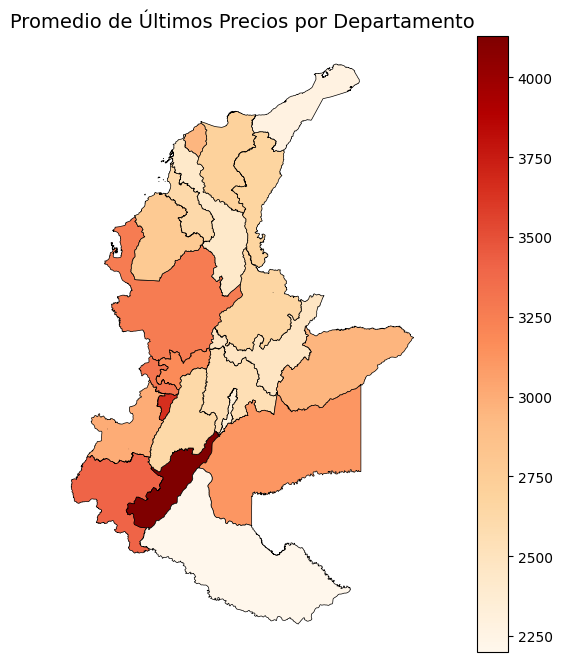

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

gdf_dept.plot(
    column="PRECIO_PROMEDIO_PUBLICADO",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title("Promedio de Últimos Precios por Departamento", fontsize=14)
ax.axis("off")

plt.show()

## Conclusion

A partir del análisis del precio promedio publicado del combustible por departamento, tomando como referencia el último precio registrado en cada municipio y luego promediando a nivel departamental, se observan varias tendencias:

**Departamentos con precios más altos**

Huila presenta el valor más elevado ($4.130), seguido por Quindío ($3.649) y Cauca ($3.411).

Esto indica que en el suroccidente y centro del país los precios tienden a estar por encima del promedio nacional.

**Departamentos con precios más bajos**

Caquetá registra el precio más bajo ($2.200), junto con La Guajira ($2.280) y Bogotá D.C. ($2.340).

Estos valores reflejan que algunas regiones periféricas y la capital mantienen precios relativamente más accesibles.

**Departamentos en rangos intermedios**

Antioquia, Valle del Cauca, Risaralda y Caldas se ubican entre los $3.000 y $3.300, lo que representa un rango medio-alto.

En contraste, Cundinamarca, Sucre, Tolima y Santander oscilan entre $2.550 y $2.650, en un rango medio-bajo.

**Cobertura de datos**

Solo aparecen 21 departamentos, lo que indica que existen territorios sin información disponible o sin registros recientes de precios. Esto es importante, pues limita la comparación completa a nivel nacional.

## Segunda georeferenciacion

Minimo de Últimos Precios por Departamento

In [46]:
# Promedio de municipios dentro de cada departamento
dept_avg = last_muni.groupby("DPTO_CCDGO").agg({
    "PRECIO_PROMEDIO_PUBLICADO": "min"
}).reset_index()

# Asegurar que los códigos sean comparables (dos dígitos con ceros)
dept_avg["DPTO_CCDGO"] = dept_avg["DPTO_CCDGO"].astype(str).str.zfill(2)
geo_df["DPTO_CCDGO"] = geo_df["DPTO_CCDGO"].astype(str).str.zfill(2)

# Crear base de departamentos con geometría
dept_base = geo_df.drop_duplicates("DPTO_CCDGO")[["DPTO_CCDGO", "DPTO_CNMBR", "geometry"]]

# Merge asegurando que todos los departamentos estén presentes
gdf_dept = dept_base.merge(dept_avg, on="DPTO_CCDGO", how="left")

In [47]:
tabla_resultados = gdf_dept[["DPTO_CCDGO", "DPTO_CNMBR", "PRECIO_PROMEDIO_PUBLICADO"]].sort_values("DPTO_CCDGO")
pd.set_option("display.max_rows", None)  # para ver todos los departamentos
display(tabla_resultados)

,DPTO_CCDGO,DPTO_CNMBR,PRECIO_PROMEDIO_PUBLICADO
1,05,ANTIOQUIA,2550
3,08,ATLANTICO,2742
2,11,BOGOTA D.C.,2340
4,13,BOLIVAR,1549
11,15,BOYACA,2329
13,17,CALDAS,2620
21,18,CAQUETA,2200
8,19,CAUCA,3141
15,20,CESAR,2419
19,23,CORDOBA,2640


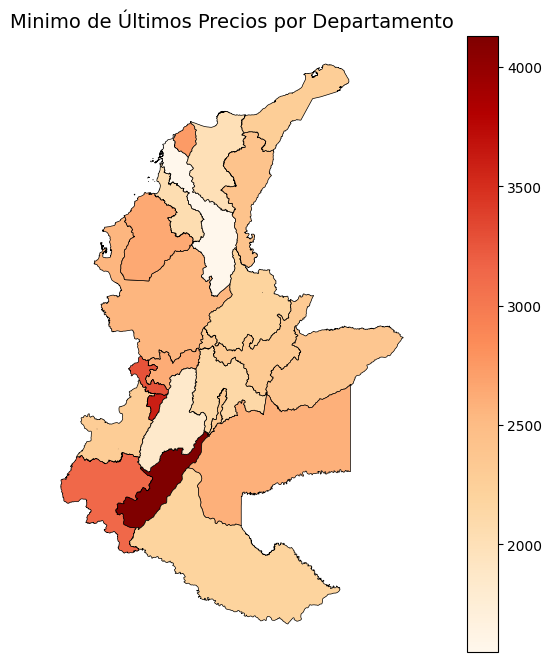

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

gdf_dept.plot(
    column="PRECIO_PROMEDIO_PUBLICADO",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title("Minimo de Últimos Precios por Departamento", fontsize=14)
ax.axis("off")

plt.show()

Al comparar los resultados del cálculo con el último precio promedio publicado frente a la alternativa de considerar el precio mínimo registrado en cada departamento, se evidencia la importancia de definir con claridad el criterio de análisis.

El uso del último promedio ofrece una visión más cercana a la realidad actual del mercado, permitiendo identificar desigualdades presentes entre regiones, mientras que el mínimo histórico refleja los momentos de mayor accesibilidad, pero puede estar condicionado por factores coyunturales o excepcionales.

Esta comparación muestra que, dependiendo del enfoque, los resultados pueden variar de manera significativa: un análisis basado en promedios recientes tiende a resaltar la estabilidad y las tendencias actuales, mientras que un análisis de mínimos pone en evidencia la variabilidad y disparidad histórica de los precios.

En consecuencia, ambos enfoques son complementarios y su elección depende del propósito del estudio: si se busca diagnosticar la situación actual, es preferible trabajar con promedios; pero si se pretende evaluar la evolución y los escenarios de mayor acceso, conviene considerar los mínimos registrados.

## Conclusion final

La georreferenciación es una herramienta fundamental en los estudios sociales porque permite conectar la información cuantitativa y cualitativa con el espacio geográfico donde ocurre. No se trata solo de ubicar un dato en un mapa, sino de darle contexto territorial, histórico y cultural.

Al trabajar con variables sociales, como precios, acceso a servicios, condiciones de vida o dinámicas poblacionales, la georreferenciación ayuda a:
- Visibilizar desigualdades: lo que en una tabla puede ser solo un número, en el mapa se convierte en una diferencia tangible entre territorios. Esto facilita identificar regiones con rezagos, brechas socioeconómicas o falta de cobertura en políticas públicas.
- Reconocer patrones espaciales: fenómenos sociales y económicos rara vez ocurren de manera aislada; suelen estar condicionados por la ubicación, la infraestructura, la cercanía a centros urbanos o la geografía física. La georreferenciación permite evidenciar relaciones de concentración o dispersión.
- Facilitar la toma de decisiones: gobiernos, instituciones y comunidades pueden orientar sus recursos de manera más justa y eficiente al saber exactamente dónde están los problemas y las oportunidades.
- Integrar múltiples capas de información: combinar datos sociales con información ambiental, de movilidad, educación, salud o seguridad para construir un panorama más completo y realista de los territorios.

En conclusión, la georreferenciación transforma los estudios sociales en análisis más profundos y útiles, porque ancla los datos a la realidad territorial. Esto no solo mejora la precisión de la investigación, sino que también fortalece la justicia social y la equidad en las decisiones, al mostrar que los problemas no son abstractos, sino que tienen lugar en espacios concretos donde viven las personas.